# Clase 3 - Practica: Preprocesamiento de Datos
## Inteligencia Artificial - Ingenieria Mecatronica

**Profesor:** Dr. Diego Stalder  
**Auxiliar:** Ing. Enrique Paiva

---

En esta practica vamos a explorar tecnicas de preprocesamiento de datos utilizando:
- NumPy y Pandas para manipulacion de datos
- Scikit-learn para preprocesamiento
- Datasets reales (Titanic y Ames Housing)
- Tecnicas de NLP basicas

**Objetivos:**
1. Aprender a manipular datos con Pandas
2. Aplicar normalizacion y estandarizacion
3. Codificar variables categoricas
4. Manejar datos faltantes
5. Crear pipelines de preprocesamiento
6. Introduccion a preprocesamiento de texto

---

## 1. Introduccion a NumPy y Pandas

### 1.1. NumPy - Arrays y Operaciones

NumPy es la libreria fundamental para computo numerico en Python.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Creacion de arrays
arr1 = np.array([1, 2, 3, 4, 5])
arr2 = np.arange(10)  # 0 a 9
arr3 = np.random.randn(5, 5)  # Matriz 5x5 de normales

print("arr1:", arr1)
print("arr2:", arr2)
print("arr3 shape:", arr3.shape)

arr1: [1 2 3 4 5]
arr2: [0 1 2 3 4 5 6 7 8 9]
arr3 shape: (5, 5)


In [2]:
# Indexing y slicing
print("Primeros 3 elementos de arr2:", arr2[:3])
print("Ultima columna de arr3:\n", arr3[:, -1])

# Extraer la fila 2 de arr3 (indice 1)
fila_2 = arr3[1, :]
print("\nFila 2 de arr3:", fila_2)

# Operaciones vectorizadas
print("\nMedia de arr2:", np.mean(arr2))
print("Desviacion de arr2:", np.std(arr2))

# Suma de arr1 multiplicado por 2
suma_doble = np.sum(arr1 * 2)
print("Suma de arr1 * 2:", suma_doble)

Primeros 3 elementos de arr2: [0 1 2]
Ultima columna de arr3:
 [-0.72525429 -0.1124878  -0.28196291 -0.46955612 -1.22521959]

Fila 2 de arr3: [ 1.16555272 -0.61440984  0.31746622  0.50549359 -0.1124878 ]

Media de arr2: 4.5
Desviacion de arr2: 2.8722813232690143
Suma de arr1 * 2: 30


### 1.2. Pandas - DataFrames y Exploracion

Pandas es la libreria principal para manipulacion de datos tabulares.

In [3]:
# Creacion de DataFrame
data = {
    'nombre': ['Ana', 'Luis', 'Carlos', 'Maria', 'Juan'],
    'edad': [25, 30, 22, 35, 28],
    'ciudad': ['Asuncion', 'CDE', 'Asuncion', 'Encarnacion', 'CDE'],
    'salario': [5000, 6000, 4500, 7000, 5500],
    'anios_exp': [2, 5, 1, 8, 3]
}
df = pd.DataFrame(data)
print("DataFrame creado:")
df

DataFrame creado:


,nombre,edad,ciudad,salario,anios_exp
0,Ana,25,Asuncion,5000,2
1,Luis,30,CDE,6000,5
2,Carlos,22,Asuncion,4500,1
3,Maria,35,Encarnacion,7000,8
4,Juan,28,CDE,5500,3


In [4]:
# Exploracion basica
print("Primeras 2 filas:")
print(df.head(2))

print("\nInformacion del DataFrame:")
df.info()

print("\nEstadisticas descriptivas:")
df.describe()

Primeras 2 filas:
  nombre  edad    ciudad  salario  anios_exp
0    Ana    25  Asuncion     5000          2
1   Luis    30       CDE     6000          5

Informacion del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   nombre     5 non-null      object
 1   edad       5 non-null      int64 
 2   ciudad     5 non-null      object
 3   salario    5 non-null      int64 
 4   anios_exp  5 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 328.0+ bytes

Estadisticas descriptivas:


,edad,salario,anios_exp
count,5.000000,5.000000,5.000000
mean,28.000000,5600.000000,3.800000
std,4.949747,961.769203,2.774887
min,22.000000,4500.000000,1.000000
25%,25.000000,5000.000000,2.000000
50%,28.000000,5500.000000,3.000000
75%,30.000000,6000.000000,5.000000
max,35.000000,7000.000000,8.000000


In [5]:
# Seleccion y filtrado
print("Personas con salario > 5000:")
print(df[df['salario'] > 5000])

print("\nNombres y edades de todos:")
print(df[['nombre', 'edad']])

# Filtrar personas de Asuncion
personas_asuncion = df[df['ciudad'] == 'Asuncion']
print("\nPersonas de Asuncion:")
print(personas_asuncion)

Personas con salario > 5000:
  nombre  edad       ciudad  salario  anios_exp
1   Luis    30          CDE     6000          5
3  Maria    35  Encarnacion     7000          8
4   Juan    28          CDE     5500          3

Nombres y edades de todos:
   nombre  edad
0     Ana    25
1    Luis    30
2  Carlos    22
3   Maria    35
4    Juan    28

Personas de Asuncion:
   nombre  edad    ciudad  salario  anios_exp
0     Ana    25  Asuncion     5000          2
2  Carlos    22  Asuncion     4500          1


## 2. Normalizacion y Estandarizacion

### 2.1. Conceptos Teoricos

- **Normalizacion (Min-Max)**: Escala al rango [0, 1]
- **Estandarizacion (Z-Score)**: Media 0, Desviacion 1

$$x_{normalizado} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

$$x_{estandarizado} = \frac{x - \mu}{\sigma}$$

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Datos de ejemplo con diferentes escalas
np.random.seed(42)
data_escalas = {
    'edad': np.random.randint(18, 70, 100),
    'ingreso': np.random.randint(20000, 150000, 100),
    'puntuacion': np.random.randint(1, 100, 100)
}
df_escalas = pd.DataFrame(data_escalas)

print("Datos originales - Estadisticas:")
print(df_escalas.describe())

Datos originales - Estadisticas:
             edad        ingreso  puntuacion
count  100.000000     100.000000      100.00
mean    43.350000   90270.820000       52.48
std     14.904663   38441.051385       30.28
min     19.000000   20206.000000        1.00
25%     31.750000   60456.500000       27.00
50%     42.000000   91251.000000       56.00
75%     57.000000  127310.750000       77.50
max     69.000000  149312.000000       98.00


In [7]:
# Aplicar StandardScaler (Estandarizacion)
scaler = StandardScaler()
df_stand = pd.DataFrame(
    scaler.fit_transform(df_escalas),
    columns=df_escalas.columns
)

print("Datos estandarizados - Estadisticas:")
print(df_stand.describe())

Datos estandarizados - Estadisticas:
               edad       ingreso    puntuacion
count  1.000000e+02  1.000000e+02  1.000000e+02
mean  -9.103829e-17 -1.786418e-16  9.381385e-17
std    1.005038e+00  1.005038e+00  1.005038e+00
min   -1.641947e+00 -1.831838e+00 -1.708697e+00
25%   -7.822007e-01 -7.794927e-01 -8.457188e-01
50%   -9.103198e-02  2.562672e-02  1.168340e-01
75%    9.204345e-01  9.684056e-01  8.304507e-01
max    1.729608e+00  1.543626e+00  1.510876e+00


In [8]:
# Aplicar MinMaxScaler (Normalizacion)
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_escalas),
    columns=df_escalas.columns
)

print("Datos normalizados - Estadisticas:")
print(df_minmax.describe())

Datos normalizados - Estadisticas:
             edad     ingreso  puntuacion
count  100.000000  100.000000  100.000000
mean     0.487000    0.542692    0.530722
std      0.298093    0.297748    0.312165
min      0.000000    0.000000    0.000000
25%      0.255000    0.311763    0.268041
50%      0.460000    0.550284    0.567010
75%      0.760000    0.829588    0.788660
max      1.000000    1.000000    1.000000


### 2.2. Visualizacion del Efecto del Escalamiento

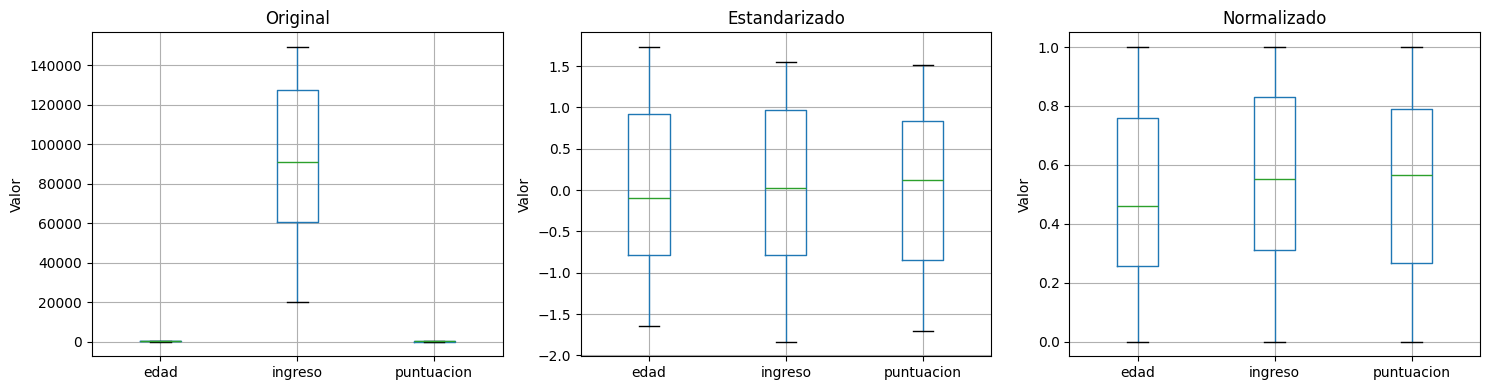

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (df, title) in enumerate([
    (df_escalas, 'Original'),
    (df_stand, 'Estandarizado'),
    (df_minmax, 'Normalizado')
]):
    df.boxplot(ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

## 3. Dataset Real: Titanic

Vamos a trabajar con el dataset del Titanic para practicar preprocesamiento.

In [10]:
# Cargar datos
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

print("Dimensiones:", titanic.shape)
print("\nPrimeras filas:")
titanic.head()

Dimensiones: (891, 12)

Primeras filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# Exploracion de datos faltantes
print("Valores faltantes por columna:")
print(titanic.isnull().sum())

print("\nPorcentaje de faltantes:")
print((titanic.isnull().sum() / len(titanic)) * 100)

Valores faltantes por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Porcentaje de faltantes:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


### 3.1. Imputacion de Datos Faltantes

In [12]:
from sklearn.impute import SimpleImputer

# Imputar Age con la media
imputer_mean = SimpleImputer(strategy='mean')
titanic_age_imputed = imputer_mean.fit_transform(titanic[['Age']])

print("Age - Media imputada:")
print(titanic_age_imputed[:10].flatten())
print(f"Media original: {titanic['Age'].mean():.2f}")
print(f"Media imputada: {titanic_age_imputed.mean():.2f}")

Age - Media imputada:
[22.         38.         26.         35.         35.         29.69911765
 54.          2.         27.         14.        ]
Media original: 29.70
Media imputada: 29.70


In [13]:
# Imputar Age con la mediana
imputer_median = SimpleImputer(strategy='median')
titanic_age_imputed_median = imputer_median.fit_transform(titanic[['Age']])

print("Age - Mediana imputada:")
print(titanic_age_imputed_median[:10].flatten())
print(f"Mediana original: {titanic['Age'].median():.2f}")
print(f"Mediana imputada: {titanic_age_imputed_median.mean():.2f}")

Age - Mediana imputada:
[22. 38. 26. 35. 35. 28. 54.  2. 27. 14.]
Mediana original: 28.00
Mediana imputada: 29.36


In [14]:
# Imputar Embarked con la moda
imputer_mode = SimpleImputer(strategy='most_frequent')
titanic_embarked_imputed = imputer_mode.fit_transform(titanic[['Embarked']])

print("Embarked - Moda imputada:")
print(pd.Series(titanic_embarked_imputed.flatten()).value_counts())
print(f"\nModa original: {titanic['Embarked'].mode()[0]}")
print(f"Moda imputada: {pd.Series(titanic_embarked_imputed.flatten()).mode()[0]}")

Embarked - Moda imputada:
S    646
C    168
Q     77
Name: count, dtype: int64

Moda original: S
Moda imputada: S


### 3.2. Codificacion de Variables Categoricas

In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding para Sex (ordinal)
le = LabelEncoder()
titanic['Sex_encoded'] = le.fit_transform(titanic['Sex'])

print("Sex - Label Encoding:")
print(titanic[['Sex', 'Sex_encoded']].head(10))

Sex - Label Encoding:
      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
5    male            1
6    male            1
7    male            1
8  female            0
9  female            0


In [16]:
# One-Hot Encoding para Embarked (nominal)
embarked_dummies = pd.get_dummies(titanic['Embarked'], prefix='Embarked')
titanic = pd.concat([titanic, embarked_dummies], axis=1)

print("Embarked - One-Hot Encoding:")
print(titanic[['Embarked', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].head(10))

Embarked - One-Hot Encoding:
  Embarked  Embarked_C  Embarked_Q  Embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True
5        Q       False        True       False
6        S       False       False        True
7        S       False       False        True
8        S       False       False        True
9        C        True       False       False


### 3.3. Pipeline de Preprocesamiento

Crear un pipeline completo para preprocesar los datos del Titanic.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definir columnas
num_cols_titanic = ['Age', 'Fare']
cat_cols_titanic = ['Sex', 'Embarked']

# Crear ColumnTransformer
preprocessor_titanic = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_titanic),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first'))
    ]), cat_cols_titanic)
])

# Crear pipeline
pipeline_titanic = Pipeline([
    ('preprocessor', preprocessor_titanic)
])

# Aplicar pipeline
titanic_processed = pipeline_titanic.fit_transform(titanic)
print("Datos procesados - Shape:", titanic_processed.shape)
print("\nPrimeras 5 filas procesadas:")
print(titanic_processed[:5])

Datos procesados - Shape: (891, 5)

Primeras 5 filas procesadas:
[[-0.56573646 -0.50244517  1.          0.          1.        ]
 [ 0.66386103  0.78684529  0.          0.          0.        ]
 [-0.25833709 -0.48885426  0.          0.          1.        ]
 [ 0.4333115   0.42073024  0.          0.          1.        ]
 [ 0.4333115  -0.48633742  1.          0.          1.        ]]


## 4. Dataset: Ames Housing

Este dataset es ideal para practicar tecnicas avanzadas de preprocesamiento.

In [18]:
# Datos simulados para practica
np.random.seed(42)
n = 1000
ames_sim = pd.DataFrame({
    'LotArea': np.random.randint(1000, 20000, n),
    'GrLivArea': np.random.randint(400, 5000, n),
    'YearBuilt': np.random.randint(1872, 2010, n),
    'OverallQual': np.random.randint(1, 11, n),
    'TotalBsmtSF': np.random.randint(0, 6000, n),
    'Neighborhood': np.random.choice(['Ames', 'College', 'OldTown', 'Edwards', 'Somerset'], n),
    'HouseStyle': np.random.choice(['1Story', '2Story', '1.5Fin', 'SLvl', 'SFoyer'], n),
    'MoSold': np.random.randint(1, 13, n),
    'SalePrice': np.random.randint(50000, 500000, n)
})

# Introducir valores faltantes
ames_sim.loc[np.random.choice(n, 150, replace=False), 'LotArea'] = np.nan
ames_sim.loc[np.random.choice(n, 50, replace=False), 'OverallQual'] = np.nan

print("Dataset simulado - Dimensiones:", ames_sim.shape)
print("\nValores faltantes:")
print(ames_sim.isnull().sum())
ames_sim.head()

Dataset simulado - Dimensiones: (1000, 9)

Valores faltantes:
LotArea         150
GrLivArea         0
YearBuilt         0
OverallQual      50
TotalBsmtSF       0
Neighborhood      0
HouseStyle        0
MoSold            0
SalePrice         0
dtype: int64


,LotArea,GrLivArea,YearBuilt,OverallQual,TotalBsmtSF,Neighborhood,HouseStyle,MoSold,SalePrice
0,16795.0,3479,2009,3.0,3327,OldTown,SLvl,10,463811
1,1860.0,1232,1929,NaN,5630,Edwards,SLvl,11,94194
2,NaN,4808,1991,3.0,5192,OldTown,2Story,1,230449
3,12964.0,3206,2004,6.0,4274,Ames,2Story,5,338997
4,12284.0,2890,1936,1.0,2259,College,1Story,10,385863


### 4.1. Normalizacion y Estandarizacion

In [19]:
# Seleccionar variables numericas
num_features_ames = ['LotArea', 'GrLivArea', 'YearBuilt', 'TotalBsmtSF']

# Estandarizar variables numericas
scaler_ames = StandardScaler()
X_scaled = scaler_ames.fit_transform(ames_sim[num_features_ames])
df_scaled = pd.DataFrame(X_scaled, columns=num_features_ames)

print("Antes de estandarizacion:")
print(ames_sim[num_features_ames].describe())

print("\nDespues de estandarizacion:")
print(df_scaled.describe())

Antes de estandarizacion:
            LotArea    GrLivArea    YearBuilt  TotalBsmtSF
count    850.000000  1000.000000  1000.000000  1000.000000
mean   10227.001176  2718.653000  1940.731000  3035.755000
std     5387.347194  1351.388778    40.297749  1749.981854
min     1009.000000   401.000000  1872.000000    11.000000
25%     5805.250000  1505.250000  1906.000000  1499.250000
50%     9837.500000  2757.500000  1940.000000  3018.500000
75%    14798.500000  3930.000000  1977.000000  4578.750000
max    19977.000000  4999.000000  2009.000000  5999.000000

Despues de estandarizacion:
            LotArea     GrLivArea     YearBuilt   TotalBsmtSF
count  8.500000e+02  1.000000e+03  1.000000e+03  1.000000e+03
mean  -9.404242e-17  1.563194e-16  1.385558e-16 -6.394885e-17
std    1.000589e+00  1.000500e+00  1.000500e+00  1.000500e+00
min   -1.712054e+00 -1.715874e+00 -1.706433e+00 -1.729314e+00
25%   -8.212492e-01 -8.983426e-01 -8.622908e-01 -8.784513e-01
50%   -7.234182e-02  2.876037e-02 -1.81490

### 4.2. Codificacion de Variables Categoricas

In [20]:
# One-Hot Encoding para Neighborhood
neighborhood_dummies = pd.get_dummies(ames_sim['Neighborhood'], prefix='Neighborhood')
ames_sim = pd.concat([ames_sim, neighborhood_dummies], axis=1)

print("One-Hot Encoding - Neighborhood:")
print(ames_sim.filter(regex='Neighborhood_').head())

One-Hot Encoding - Neighborhood:
   Neighborhood_Ames  Neighborhood_College  Neighborhood_Edwards  \
0              False                 False                 False   
1              False                 False                  True   
2              False                 False                 False   
3               True                 False                 False   
4              False                  True                 False   

   Neighborhood_OldTown  Neighborhood_Somerset  
0                  True                  False  
1                 False                  False  
2                  True                  False  
3                 False                  False  
4                 False                  False  


In [21]:
# One-Hot Encoding para HouseStyle
house_dummies = pd.get_dummies(ames_sim['HouseStyle'], prefix='HouseStyle')
ames_sim = pd.concat([ames_sim, house_dummies], axis=1)

print("One-Hot Encoding - HouseStyle:")
print(ames_sim.filter(regex='HouseStyle_').head())

One-Hot Encoding - HouseStyle:
   HouseStyle_1.5Fin  HouseStyle_1Story  HouseStyle_2Story  HouseStyle_SFoyer  \
0              False              False              False              False   
1              False              False              False              False   
2              False              False               True              False   
3              False              False               True              False   
4              False               True              False              False   

   HouseStyle_SLvl  
0             True  
1             True  
2            False  
3            False  
4            False  


### 4.3. Codificacion Ciclica (Meses)

In [22]:
# Codificacion ciclica para MoSold
def cyclic_encode(series, period):
    """Codifica una variable ciclica usando seno y coseno."""
    sin = np.sin(2 * np.pi * series / period)
    cos = np.cos(2 * np.pi * series / period)
    return sin, cos

mes_sin, mes_cos = cyclic_encode(ames_sim['MoSold'], 12)
ames_sim['MoSold_sin'] = mes_sin
ames_sim['MoSold_cos'] = mes_cos

print("Codificacion ciclica de meses:")
print(ames_sim[['MoSold', 'MoSold_sin', 'MoSold_cos']].head(15))

Codificacion ciclica de meses:
    MoSold  MoSold_sin    MoSold_cos
0       10   -0.866025  5.000000e-01
1       11   -0.500000  8.660254e-01
2        1    0.500000  8.660254e-01
3        5    0.500000 -8.660254e-01
4       10   -0.866025  5.000000e-01
5        9   -1.000000 -1.836970e-16
6        1    0.500000  8.660254e-01
7        1    0.500000  8.660254e-01
8        4    0.866025 -5.000000e-01
9        4    0.866025 -5.000000e-01
10       2    0.866025  5.000000e-01
11       9   -1.000000 -1.836970e-16
12       9   -1.000000 -1.836970e-16
13       2    0.866025  5.000000e-01
14       9   -1.000000 -1.836970e-16


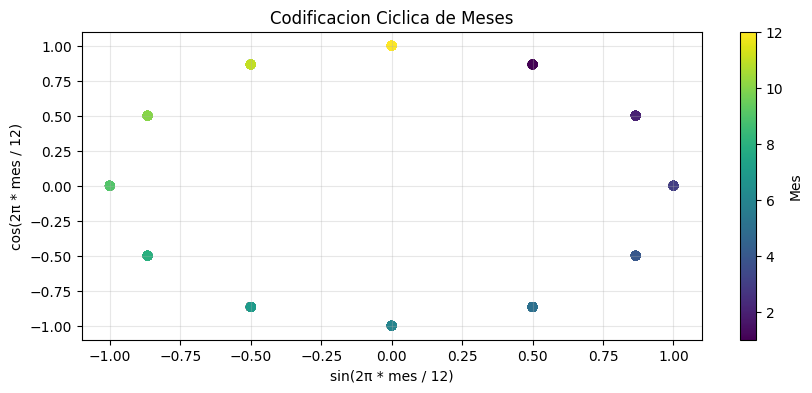

In [23]:
# Visualizacion de la codificacion ciclica
plt.figure(figsize=(10, 4))
plt.scatter(ames_sim['MoSold_sin'], ames_sim['MoSold_cos'], 
            c=ames_sim['MoSold'], cmap='viridis')
plt.colorbar(label='Mes')
plt.xlabel('sin(2π * mes / 12)')
plt.ylabel('cos(2π * mes / 12)')
plt.title('Codificacion Ciclica de Meses')
plt.grid(True, alpha=0.3)
plt.show()

### 4.4. Pipeline Completo para Ames Housing

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Definir columnas
num_cols_ames = ['LotArea', 'GrLivArea', 'YearBuilt', 'TotalBsmtSF']
cat_cols_ames = ['Neighborhood', 'HouseStyle']

# Crear ColumnTransformer completo
preprocessor_ames = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_ames),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first'))
    ]), cat_cols_ames)
])

# Crear pipeline
pipeline_ames = Pipeline([
    ('preprocessor', preprocessor_ames)
])

# Aplicar pipeline
X_processed_ames = pipeline_ames.fit_transform(ames_sim)
print("Datos procesados - Shape:", X_processed_ames.shape)

Datos procesados - Shape: (1000, 12)


## 5. Preprocesamiento de Texto (NLP)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Texto de ejemplo
textos = [
    "El gato negro salto sobre la mesa",
    "El perro ladra en el jardin",
    "El gato y el perro son amigos",
    "La mesa esta en el jardin",
    "El gato blanco corre rapidamente"
]

# Crear CountVectorizer
vectorizer = CountVectorizer()
X_count = vectorizer.fit_transform(textos)

print("CountVectorizer - Matriz de frecuencias:")
print(pd.DataFrame(X_count.toarray(), columns=vectorizer.get_feature_names_out()))

CountVectorizer - Matriz de frecuencias:
   amigos  blanco  corre  el  en  esta  gato  jardin  la  ladra  mesa  negro  \
0       0       0      0   1   0     0     1       0   1      0     1      1   
1       0       0      0   2   1     0     0       1   0      1     0      0   
2       1       0      0   2   0     0     1       0   0      0     0      0   
3       0       0      0   1   1     1     0       1   1      0     1      0   
4       0       1      1   1   0     0     1       0   0      0     0      0   

   perro  rapidamente  salto  sobre  son  
0      0            0      1      1    0  
1      1            0      0      0    0  
2      1            0      0      0    1  
3      0            0      0      0    0  
4      0            1      0      0    0  


In [26]:
# Crear TfidfVectorizer
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(textos)

print("TF-IDF - Matriz de pesos:")
print(pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out()).round(3))

TF-IDF - Matriz de pesos:
   amigos  blanco  corre     el     en   esta   gato  jardin     la  ladra  \
0     0.0   0.000  0.000  0.214  0.000  0.000  0.300   0.000  0.362  0.000   
1     0.0   0.000  0.000  0.485  0.411  0.000  0.000   0.411  0.000  0.509   
2     0.5   0.000  0.000  0.476  0.000  0.000  0.335   0.000  0.000  0.000   
3     0.0   0.000  0.000  0.243  0.412  0.511  0.000   0.412  0.412  0.000   
4     0.0   0.522  0.522  0.249  0.000  0.000  0.349   0.000  0.000  0.000   

    mesa  negro  perro  rapidamente  salto  sobre  son  
0  0.362  0.448  0.000        0.000  0.448  0.448  0.0  
1  0.000  0.000  0.411        0.000  0.000  0.000  0.0  
2  0.000  0.000  0.403        0.000  0.000  0.000  0.5  
3  0.412  0.000  0.000        0.000  0.000  0.000  0.0  
4  0.000  0.000  0.000        0.522  0.000  0.000  0.0  


In [27]:
# Ejemplo con dataset real (Titanic - nombres)
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorizar nombres de pasajeros
tfidf_names = TfidfVectorizer(max_features=20, stop_words='english')
X_names = tfidf_names.fit_transform(titanic['Name'].fillna(''))

print("TF-IDF de nombres - Shape:", X_names.shape)
print("\nTerminos mas importantes:")
print(tfidf_names.get_feature_names_out()[:10])

TF-IDF de nombres - Shape: (891, 20)

Terminos mas importantes:
['anna' 'arthur' 'charles' 'edward' 'elizabeth' 'frederick' 'george'
 'henry' 'james' 'johan']


## 6. Embedding Space (Word2Vec Simulado)

Visualizacion de embeddings de palabras.

In [28]:
from sklearn.decomposition import PCA

# Palabras y sus embeddings simulados
palabras = ['gato', 'perro', 'gato_blanco', 'perro_negro', 'mesa', 
            'jardin', 'correr', 'saltar', 'ladrar', 'amigo']

# Crear embeddings con estructura semantica
np.random.seed(42)
embeddings = np.random.randn(len(palabras), 50)

# Aplicar PCA para visualizacion 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print("Embeddings - Dimension:", embeddings.shape)
print("\nEmbeddings 2D:")
print(embeddings_2d[:5])

Embeddings - Dimension: (10, 50)

Embeddings 2D:
[[ 3.64150189 -0.88427807]
 [ 1.36029988  3.79397435]
 [-0.27941308 -0.82005675]
 [-2.13035349 -2.54050397]
 [ 4.43411294 -4.02392448]]


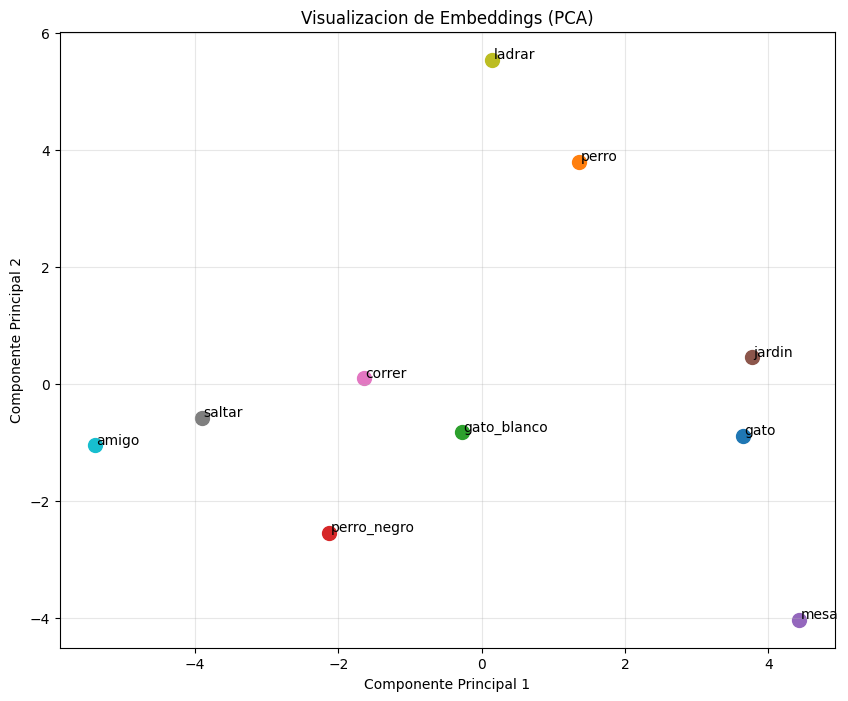

In [29]:
# Graficar embeddings
plt.figure(figsize=(10, 8))
for i, palabra in enumerate(palabras):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], s=100)
    plt.annotate(palabra, (embeddings_2d[i, 0] + 0.02, embeddings_2d[i, 1] + 0.02))

plt.title('Visualizacion de Embeddings (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Ejercicios Practicos

### Ejercicio 1: Preprocesamiento del Titanic

Completa el pipeline para preprocesar el dataset del Titanic:
1. Imputar Age con la mediana
2. Imputar Embarked con la moda
3. Estandarizar Age y Fare
4. One-Hot Encoder Sex y Embarked

In [30]:
# Solucion - Ejercicio 1
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Definir columnas
num_cols = ['Age', 'Fare']
cat_cols = ['Sex', 'Embarked']

# Crear preprocesador
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first'))
    ]), cat_cols)
])

# Crear y aplicar pipeline
pipeline = Pipeline([('preprocessor', preprocessor)])
X_processed = pipeline.fit_transform(titanic)
print("Datos procesados - Shape:", X_processed.shape)

Datos procesados - Shape: (891, 5)


### Ejercicio 2: Binning de Edad

Discretiza la variable Age del Titanic en 5 grupos (bins).

In [34]:
from sklearn.preprocessing import KBinsDiscretizer
import pandas as pd

# Rellenar valores faltantes una sola vez
age_filled = titanic[['Age']].fillna(titanic['Age'].median())

# Equal Width Binning (uniform)
kbd_width = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
age_bins_width = kbd_width.fit_transform(age_filled)

# Equal Frequency Binning (quantile)
kbd_freq = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
age_bins_freq = kbd_freq.fit_transform(age_filled)

# Mostrar distribuciones
print("Equal Width Bins - Distribución:")
print(pd.Series(age_bins_width.flatten()).value_counts().sort_index())

print("\nEqual Frequency Bins - Distribución:")
print(pd.Series(age_bins_freq.flatten()).value_counts().sort_index())

Equal Width Bins - Distribución:
0.0    100
1.0    523
2.0    188
3.0     69
4.0     11
Name: count, dtype: int64

Equal Frequency Bins - Distribución:
0.0    164
1.0    173
2.0    366
3.0    188
Name: count, dtype: int64


h:\Anaconda\envs\deepf\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
h:\Anaconda\envs\deepf\lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


### Ejercicio 3: Embeddings Personalizados

Crea embeddings para 10 palabras relacionadas con tu area de estudio (mecatronica) y visualizalos.

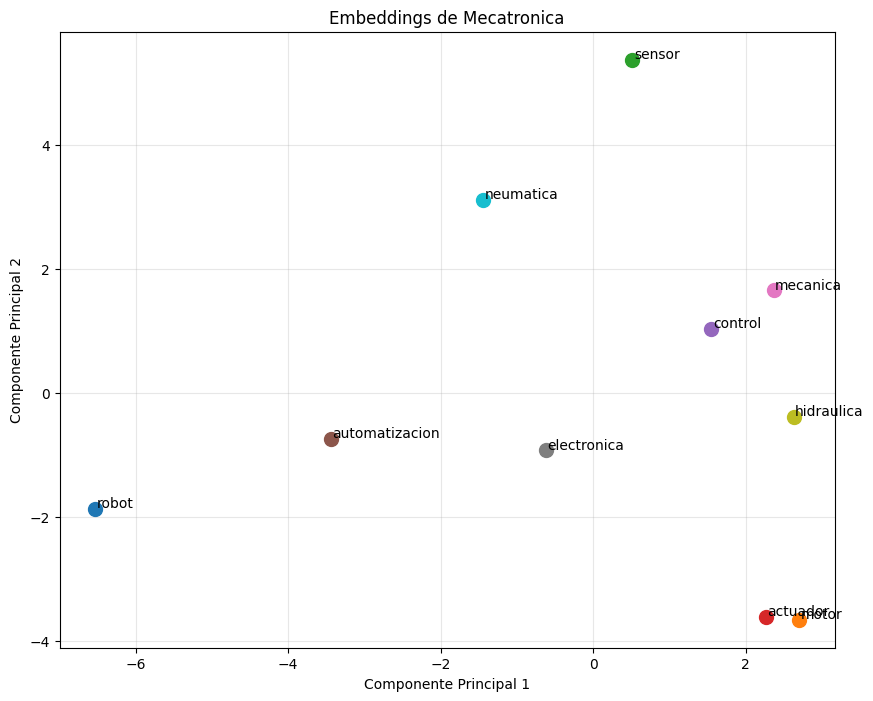

In [32]:
# Palabras relacionadas con mecatronica
palabras_mecatronica = [
    'robot', 'motor', 'sensor', 'actuador', 'control',
    'automatizacion', 'mecanica', 'electronica', 'hidraulica', 'neumatica'
]

# Crear embeddings
np.random.seed(123)
embeddings_meca = np.random.randn(len(palabras_mecatronica), 50)

# PCA para visualizacion
pca_meca = PCA(n_components=2)
embeddings_meca_2d = pca_meca.fit_transform(embeddings_meca)

# Graficar
plt.figure(figsize=(10, 8))
for i, palabra in enumerate(palabras_mecatronica):
    plt.scatter(embeddings_meca_2d[i, 0], embeddings_meca_2d[i, 1], s=100)
    plt.annotate(palabra, (embeddings_meca_2d[i, 0] + 0.02, embeddings_meca_2d[i, 1] + 0.02))

plt.title('Embeddings de Mecatronica')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, alpha=0.3)
plt.show()

---

## Resumen de Tecnicas de Preprocesamiento

| **Tecnica** | **Cuando usar** | **Scikit-learn** |
|-------------|-----------------|------------------|
| Estandarizacion | Modelos basados en distancia | `StandardScaler` |
| Normalizacion | Redes Neuronales | `MinMaxScaler` |
| One-Hot Encoding | Categoricas nominales | `OneHotEncoder` |
| Label Encoding | Categoricas ordinales | `LabelEncoder` |
| Codificacion Ciclica | Variables temporales | `FunctionTransformer` |
| Imputacion | Datos faltantes | `SimpleImputer` |
| Binning | Discretizacion | `KBinsDiscretizer` |
| TF-IDF | Texto | `TfidfVectorizer` |

---

*Material preparado para la clase del 29 de julio de 2026*